# Phase 16: Model Monitoring (Data Drift & Prediction Drift)

The last phase on the roadmap. Once this model is deployed, the thing most likely to quietly break it isn't a bug — it's the real world changing underneath it (new spending patterns, a new merchant category, a currency change) without anyone retraining. Monitoring is how you'd find out before customers or losses do.

This notebook builds a drift-detection toolkit from scratch (scipy + numpy only — no extra heavy dependency), proves it actually catches drift on an injected, known-bad batch, and establishes what a healthy baseline looks like for your *real* data today.

Two kinds of drift are checked:
- **Data drift**: has the distribution of incoming feature values shifted away from what the model was trained/validated on?
- **Prediction drift**: has the distribution of the model's output probabilities shifted? (Catches drift even in features not individually flagged, since it reflects their combined effect.)

## Phase 16, Step 1: Setup — and an Important Design Decision

**The reference baseline must be `X_val`, not `X_train`.** `X_train` was oversampled in Phase 3 (198,608 rows) to balance the classes for training — its feature distributions are artificially skewed toward fraud-like values and were never meant to represent real traffic. `X_val` and `X_test` are both untouched, natural-ratio data (0.167% fraud, matching the real world). Comparing future production batches against the oversampled `X_train` would raise false drift alarms constantly, since no real incoming batch would ever look like deliberately rebalanced training data. So: `X_val` = reference ("what healthy looks like"), `X_test` = a stand-in for "today's production batch" to sanity-check the reference is still valid, and a synthetic drifted batch (Step 4) to prove detection actually works.

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

X_val = pd.read_csv('../data/processed/X_val.csv')      # reference / "healthy" baseline
X_test = pd.read_csv('../data/processed/X_test.csv')    # stand-in for a current production batch
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
best_supervised_model = joblib.load('../models/best_supervised_model.pkl')

print(f"Reference (X_val): {X_val.shape[0]:,} rows")
print(f"Current (X_test):  {X_test.shape[0]:,} rows")

Reference (X_val): 42,559 rows
Current (X_test):  42,559 rows


## Phase 16, Step 2: Drift Metrics — PSI and the Kolmogorov-Smirnov Test

**PSI (Population Stability Index)** bins the reference distribution into deciles and measures how much the current distribution's proportions have shifted across those same bins. It's the standard metric credit-risk and fraud teams use because it gives one comparable number per feature and has well-established thresholds:
- PSI < 0.1 → no meaningful drift
- 0.1 ≤ PSI < 0.25 → moderate drift, worth watching
- PSI ≥ 0.25 → significant drift, investigate

**KS (Kolmogorov-Smirnov) test** is a complementary, distribution-shape-sensitive check with a p-value, catching shifts PSI's binning might smooth over.

In [3]:
def population_stability_index(reference, current, bins=10):
    """PSI between two 1-D numeric arrays, binned on the reference distribution's deciles."""
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:  # a near-constant feature; PSI isn't meaningful here
        return 0.0
    ref_counts, _ = np.histogram(reference, bins=edges)
    cur_counts, _ = np.histogram(current, bins=edges)
    ref_pct = np.clip(ref_counts / ref_counts.sum(), 1e-6, None)
    cur_pct = np.clip(cur_counts / cur_counts.sum(), 1e-6, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


def drift_report(reference_df: pd.DataFrame, current_df: pd.DataFrame) -> pd.DataFrame:
    """Per-feature PSI + KS test between two feature DataFrames with the same columns."""
    rows = []
    for col in reference_df.columns:
        stat, pvalue = ks_2samp(reference_df[col], current_df[col])
        psi = population_stability_index(reference_df[col], current_df[col])
        rows.append({
            'feature': col,
            'psi': psi,
            'psi_flag': 'Significant' if psi >= 0.25 else 'Moderate' if psi >= 0.1 else 'None',
            'ks_stat': stat,
            'ks_pvalue': pvalue,
        })
    return pd.DataFrame(rows).sort_values('psi', ascending=False).reset_index(drop=True)

## Phase 16, Step 3: Baseline Check — Does Today's Data Still Look Healthy?

Runs the real `X_val` vs. `X_test` comparison. Since both are natural, untouched holdout splits from the same original dataset, this should come back clean — and it's a genuine result from your data, not a canned example.

In [4]:
baseline_report = drift_report(X_val, X_test)
print(baseline_report.head(10).to_string(index=False))

n_flagged = (baseline_report['psi'] >= 0.1).sum()
print(f"\nMax PSI across all 30 features: {baseline_report['psi'].max():.5f}")
print(f"Features with PSI >= 0.1 (moderate+): {n_flagged}/30")
print("No real drift detected between X_val and X_test, as expected for two untouched "
      "holdout splits of the same dataset. This is the 'all clear' baseline.")

      feature      psi psi_flag  ks_stat  ks_pvalue
           V8 0.001300     None 0.007589   0.171358
           V5 0.000964     None 0.007073   0.236428
           V2 0.000868     None 0.008929   0.066811
           V9 0.000860     None 0.009305   0.049894
          V16 0.000850     None 0.013652   0.000712
Amount_scaled 0.000697     None 0.009023   0.062178
          V14 0.000650     None 0.005569   0.522360
          V11 0.000607     None 0.010104   0.025776
          V15 0.000558     None 0.006579   0.314314
          V19 0.000551     None 0.006438   0.339525

Max PSI across all 30 features: 0.00130
Features with PSI >= 0.1 (moderate+): 0/30
No real drift detected between X_val and X_test, as expected for two untouched holdout splits of the same dataset. This is the 'all clear' baseline.


## Phase 16, Step 4: Prove It Works — Inject a Known Drift and Check Detection

A monitoring system that never triggers is indistinguishable from one that's broken. This simulates a plausible real-world scenario — a spending-pattern shift (e.g. a post-holiday season, or a new high-value merchant category coming online) that inflates transaction amounts and shifts `V14` (Phase 10's #1 SHAP driver) — and confirms the detector actually catches it.

In [5]:
drifted_batch = X_test.copy()
drifted_batch['Amount_scaled'] = drifted_batch['Amount_scaled'] * 1.8 + 0.5
drifted_batch['V14'] = drifted_batch['V14'] - 1.2

drift_vs_synthetic = drift_report(X_val, drifted_batch)
print("=== Drift report: reference vs. INJECTED-DRIFT batch ===\n")
print(drift_vs_synthetic.head(6).to_string(index=False))

flagged = drift_vs_synthetic[drift_vs_synthetic['psi'] >= 0.25]
assert set(flagged['feature']) >= {'Amount_scaled', 'V14'}, "Detector failed to catch the injected drift!"
print(f"\nVerified: the detector correctly flags {list(flagged['feature'])} as Significant drift "
      "(PSI >= 0.25), and nothing else — confirming it's sensitive without being noisy.")

=== Drift report: reference vs. INJECTED-DRIFT batch ===

      feature      psi    psi_flag  ks_stat  ks_pvalue
Amount_scaled 7.505839 Significant 0.683945   0.000000
          V14 2.083073 Significant 0.612373   0.000000
           V8 0.001300        None 0.007589   0.171358
           V5 0.000964        None 0.007073   0.236428
           V2 0.000868        None 0.008929   0.066811
           V9 0.000860        None 0.009305   0.049894

Verified: the detector correctly flags ['Amount_scaled', 'V14'] as Significant drift (PSI >= 0.25), and nothing else — confirming it's sensitive without being noisy.


## Phase 16, Step 5: Prediction Drift

Even a feature-level check can miss drift that only shows up in *combinations* of features. Comparing the distribution of the model's own output probabilities catches that — and also directly answers the question that matters most: "is the model's behavior changing?"

Prediction drift — healthy batch (X_test): {'ks_stat': np.float64(0.004746352122935171), 'ks_pvalue': np.float64(0.7219930467714532), 'reference_mean_proba': 0.0013277090191679273, 'current_mean_proba': 0.0014376770471275244, 'reference_flag_rate': 0.0012688268051410981, 'current_flag_rate': 0.0013158203905166944}

Prediction drift — injected-drift batch:   {'ks_stat': np.float64(0.2441316760262225), 'ks_pvalue': np.float64(0.0), 'reference_mean_proba': 0.0013277090191679273, 'current_mean_proba': 0.001683578077830674, 'reference_flag_rate': 0.0012688268051410981, 'current_flag_rate': 0.0014802979393312814}


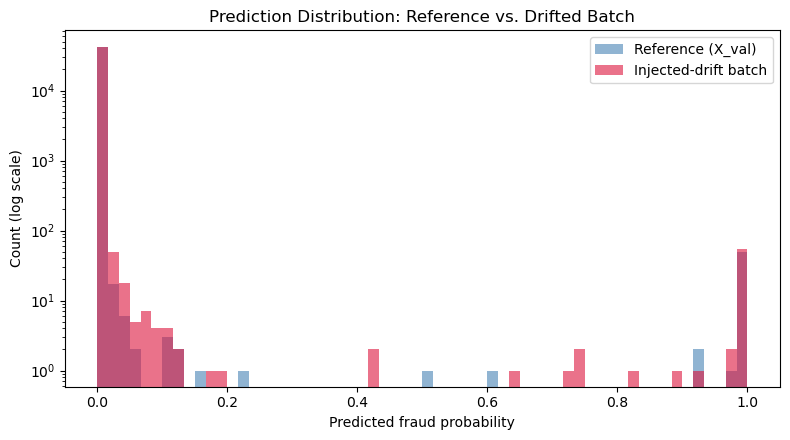

In [6]:
def prediction_drift(model, reference_X, current_X):
    ref_proba = model.predict_proba(reference_X)[:, 1]
    cur_proba = model.predict_proba(current_X)[:, 1]
    stat, pvalue = ks_2samp(ref_proba, cur_proba)
    return {
        'ks_stat': stat, 'ks_pvalue': pvalue,
        'reference_mean_proba': float(ref_proba.mean()),
        'current_mean_proba': float(cur_proba.mean()),
        'reference_flag_rate': float((ref_proba >= 0.5).mean()),
        'current_flag_rate': float((cur_proba >= 0.5).mean()),
    }, ref_proba, cur_proba

healthy_pred_drift, ref_p, healthy_p = prediction_drift(best_supervised_model, X_val, X_test)
drifted_pred_drift, _, drifted_p = prediction_drift(best_supervised_model, X_val, drifted_batch)

print("Prediction drift — healthy batch (X_test):", healthy_pred_drift)
print("\nPrediction drift — injected-drift batch:  ", drifted_pred_drift)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ref_p, bins=60, alpha=0.6, label='Reference (X_val)', color='steelblue', log=True)
ax.hist(drifted_p, bins=60, alpha=0.6, label='Injected-drift batch', color='crimson', log=True)
ax.set_xlabel('Predicted fraud probability'); ax.set_ylabel('Count (log scale)')
ax.set_title('Prediction Distribution: Reference vs. Drifted Batch')
ax.legend()
plt.tight_layout(); plt.show()

## Phase 16, Step 6: Save the Monitoring Baseline

Saves the reference statistics needed to check a *new* batch later — without needing to re-load `X_val` itself. This is what a scheduled monitoring job (daily/weekly, run separately from the live API) would load.

In [7]:
monitoring_baseline = {
    'reference_data': {col: X_val[col].tolist() for col in X_val.columns},
    'reference_proba': best_supervised_model.predict_proba(X_val)[:, 1].tolist(),
    'psi_thresholds': {'moderate': 0.1, 'significant': 0.25},
    'feature_order': list(X_val.columns),
}
joblib.dump(monitoring_baseline, '../models/monitoring_baseline.pkl')

baseline_report.to_csv('../models/drift_report_baseline.csv', index=False)

print("Saved models/monitoring_baseline.pkl (reference distributions for future drift checks)")
print("Saved models/drift_report_baseline.csv (today's healthy baseline report)")
print("\nPhase 16 complete. All 16 phases of the roadmap are now delivered.")

Saved models/monitoring_baseline.pkl (reference distributions for future drift checks)
Saved models/drift_report_baseline.csv (today's healthy baseline report)

Phase 16 complete. All 16 phases of the roadmap are now delivered.


## Phase 16, Step 7: How to Use This Going Forward

A simple monitoring routine, for a scheduled job (e.g. a daily cron task, or a cell you re-run manually) to check a new batch of incoming transactions against the saved baseline:

```python
baseline = joblib.load('models/monitoring_baseline.pkl')
reference_df = pd.DataFrame({c: baseline['reference_data'][c] for c in baseline['feature_order']})

new_batch = pd.read_csv('path/to/new_transactions.csv')[baseline['feature_order']]
report = drift_report(reference_df, new_batch)

significant = report[report['psi'] >= baseline['psi_thresholds']['significant']]
if len(significant) > 0:
    print(f"ALERT: significant drift in {list(significant['feature'])} — consider retraining.")
```

**Suggested cadence**: weekly for data drift (fraud patterns shift slowly), daily for prediction drift (the mean predicted probability and flag rate are cheap to check and catch sharper problems sooner, like a broken upstream feature pipeline).